In [38]:
#Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.ensemble import RandomForestClassifier

In [39]:
#Loading data. (renamed csv files for simplicity)
test = 'C:/Users/firea/Desktop/project_trace/churn_testing.csv'
train = 'C:/Users/firea/Desktop/project_trace/churn_training.csv'

test_df = pd.read_csv(test)
train_df = pd.read_csv(train)

In [40]:
#Displays number of data entries and columns in dataset
train_df.shape

(440833, 12)

In [41]:
#column info
train_df.dtypes

CustomerID           float64
Age                  float64
Gender                object
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type     object
Contract Length       object
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object

In [42]:
test_df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [43]:
train_df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [44]:
train_df = train_df.dropna()
train_df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [45]:
train_df = train_df.drop(columns=['CustomerID'], errors='ignore')
test_df  = test_df.drop(columns=['CustomerID'], errors='ignore')


train_df['Churn'] = (
    train_df['Churn']
    .replace({'Churned': 1, 'Active': 0})
    .astype(float)
    .astype(int)
)

test_df['Churn'] = (
    test_df['Churn']
    .replace({'Churned': 1, 'Active': 0})
    .astype(float)
    .astype(int)
)

train_df['Gender'] = (train_df['Gender'] == 'Female').astype(int)
test_df['Gender']  = (test_df['Gender'] == 'Female').astype(int)

sub_mapping = {
    'Standard':0,
    'Premium':1,
    'Other':2
}
train_df['Subscription Type'] = train_df['Subscription Type'].map(sub_mapping)
test_df['Subscription Type']  = test_df['Subscription Type'].map(sub_mapping)

contract_mapping = {
    'Annual': 0,
    'Quarterly': 1,
    'Other': 2
}
train_df['Contract Length'] = train_df['Contract Length'].map(contract_mapping)
test_df['Contract Length']  = test_df['Contract Length'].map(contract_mapping)


In [49]:
X_trn = train_df.loc[:, train_df.columns != 'Churn']
y_trn = train_df.loc[:, train_df.columns == 'Churn']

X_tst = test_df.loc[:, test_df.columns != 'Churn']
y_tst = test_df.loc[:, test_df.columns == 'Churn']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_trn, y_trn.values.ravel())

train_acc = rf.score(X_trn, y_trn)
test_acc  = rf.score(X_tst, y_tst)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

y_pred = rf.predict(X_tst)

from sklearn.metrics import classification_report

print(classification_report(y_tst, y_pred))





Train Accuracy: 1.0
Test Accuracy : 0.5033864603721999
              precision    recall  f1-score   support

           0       0.98      0.06      0.11     33881
           1       0.49      1.00      0.66     30493

    accuracy                           0.50     64374
   macro avg       0.73      0.53      0.38     64374
weighted avg       0.75      0.50      0.37     64374



In [47]:
importances = rf.feature_importances_
feature_names = X_trn.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(importance_df)

             feature  importance
4      Support Calls    0.302236
8        Total Spend    0.208653
0                Age    0.142620
7    Contract Length    0.140102
5      Payment Delay    0.125564
9   Last Interaction    0.037967
1             Gender    0.029642
2             Tenure    0.009107
3    Usage Frequency    0.002945
6  Subscription Type    0.001165


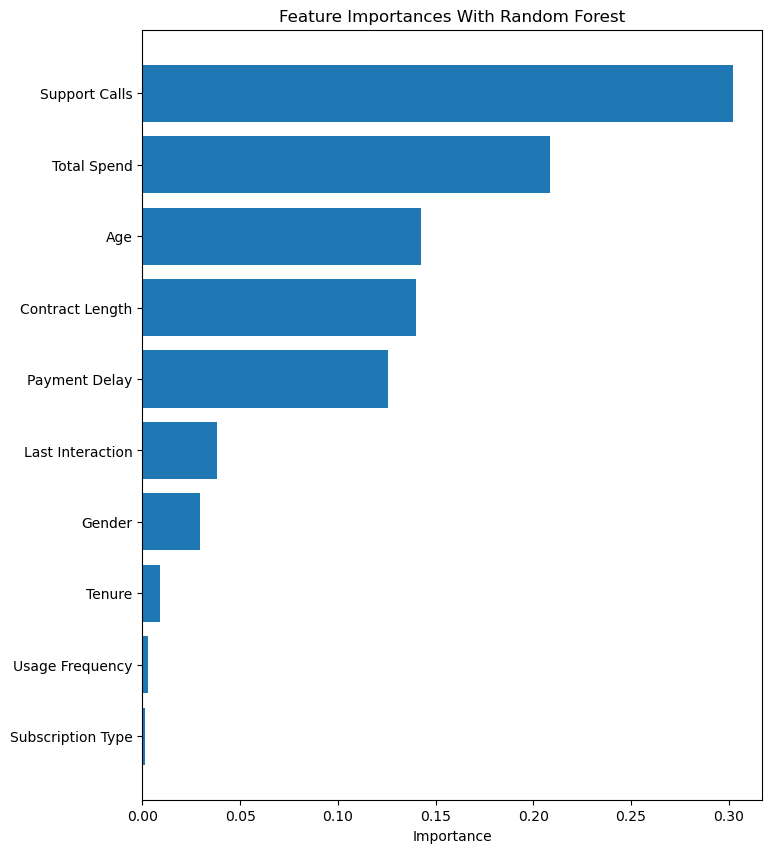

In [48]:
plt.figure(figsize=(8, 10))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importances With Random Forest")
plt.xlabel("Importance")
plt.show()